<a href="https://colab.research.google.com/github/Innovation-course/Code/blob/main/Drone_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = "/content/drive/MyDrive/Msc/Innovation/data_SAAB_SIRS_77GHz_FMCW.npy"

In [5]:
data = np.load(file_path, allow_pickle=True)

In [6]:
import pandas as pd

column_names = [
    "Target type",
    "Radar data",
    "Range",
    "Time",
    "Dataset split",
    "Edge indicator"
]

df = pd.DataFrame(data, columns=column_names)

df.head()

,Target type,Radar data,Range,Time,Dataset split,Edge indicator
0,[D1],"[[(-0.0803837295206183-0.024996274181930858j),...","[[62.26415142983489], [62.26415142983489], [62...","[[0.04242135490599999], [0.14313034690999998],...","[[2], [3], [1], [3], [1], [1], [1], [1], [3], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ..."
1,[D1],"[[(0.1592469814114204-0.3764412575384074j), (0...","[[116.03773675560139], [116.03773675560139], [...","[[0.04531640558899999], [0.148743200275], [0.2...","[[3], [1], [3], [1], [1], [1], [2], [2], [1], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ..."
2,[D1],"[[(-0.36744600235662883-0.17434743507810269j),...","[[75.47169870283017], [75.47169870283017], [75...","[[0.04389842158099999], [0.14448924825099999],...","[[1], [1], [1], [1], [2], [1], [1], [3], [2], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ..."
3,[D1],"[[(-0.7918969406816826-0.0388248167751634j), (...","[[145.28302000294806], [145.28302000294806], [...","[[0.04372117357999999], [0.14372117358], [0.24...","[[1], [2], [3], [1], [3], [1], [3], [1], [1], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ..."
4,[D1],"[[(0.08721619353018038-0.05631563733996364j), ...","[[22.641509610849056], [22.641509610849056], [...","[[0.03592226153599999], [0.13604042687], [0.23...","[[1], [1], [3], [1], [3], [1], [1], [1], [1], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ..."


In [7]:
print(data[0])

[array(['D1'], dtype='<U2')
 array([[-0.08038373-0.02499627j,  0.04756861+0.03649223j,
         -0.02759177-0.05794828j, ...,  0.13447953+0.19529996j,
          0.2154778 -0.0759136j ,  0.12028819+0.54258756j],
        [-0.22068575+0.24157512j,  0.03672643-0.02921679j,
          0.18087524-0.17235501j, ..., -0.25833575-0.15397716j,
         -0.2053239 +0.20844556j,  0.16247591+0.06850156j],
        [ 0.24550907-0.09061331j, -0.08463852+0.01317374j,
         -0.18998626+0.20569023j, ..., -0.01846222-0.32420358j,
          0.22244815-0.07332366j,  0.18568661+0.19106105j],
        ...,
        [-0.13386504+0.29145525j, -0.27262581-0.20920668j,
         -0.34563091+0.08175469j, ...,  0.13330374+0.07233688j,
         -0.20246152+0.57935345j, -0.242257  +0.16050154j],
        [ 0.19520528-0.21789863j,  0.1194517 -0.40258428j,
         -0.41926386-0.14130664j, ...,  0.09871458-0.092074j  ,
          0.01588914+0.26406935j, -0.21304606-0.46370891j],
        [-0.27569597+0.02700667j,  0.1410001

In [8]:
radar = data[0, 1]
print(radar.shape)

(1280, 1228)


In [9]:
target_types = [row[0][0] for row in data]

print(target_types)

[np.str_('D1'), np.str_('D1'), np.str_('D1'), np.str_('D1'), np.str_('D1'), np.str_('D1'), np.str_('D1'), np.str_('D1'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D2'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D4'), np.str_('D4'), np.str_('D4'), np.str_('D4'), np.str_('D5'), np.str_('D5'), np.str_('D5'), np.str_('D5'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('D6'), np.str_('human_walk'), np.str_('human_walk'), np.str_('human_walk'), np.str_('human_walk'), np.str_('human_run'), np.str_('human_walk'), np.str_('human_run'), np.str_('human_walk'), np.str_('human_run'), np.str_('human_walk'), np.str_('human_run'), np.str_('seagull'), np.str_('seagull'), np.str_('seagull'), np.str_('seagull'), np.str_('s

In [10]:
ranges = data[0, 2]

print(ranges)
print("Minimum:", ranges.min(), "m")
print("Maximum:", ranges.max(), "m")

[[62.26415143]
 [62.26415143]
 [62.26415143]
 ...
 [62.26415143]
 [62.26415143]
 [62.26415143]]
Minimum: 61.32075519604951 m
Maximum: 62.26415142983489 m


In [12]:



drone_labels = {"D1", "D2", "D3", "D4", "D5", "D6"}

X_train, y_train = [], []
X_val, y_val = [], []
X_test, y_test = [], []


for i in range(len(data)):

    target = data[i, 0][0]
    radar = data[i, 1]          # shape: (1280, N)
    splits = np.asarray(data[i, 4]).flatten()

    # Binary label
    label = 1 if target in drone_labels else 0

    # Optional: exclude corner reflector
    if target == "CR":
        continue

    for j in range(radar.shape[1]):

        segment = radar[:, j]   # shape: (1280,)

        # reshape into 5 range cells x 256 azimuth samples
        segment = segment.reshape(5, 256)

        # magnitude of complex radar signal
        segment = np.abs(segment)

        split = splits[j]

        if split == 1:
            X_train.append(segment)
            y_train.append(label)

        elif split == 2:
            X_val.append(segment)
            y_val.append(label)

        elif split == 3:
            X_test.append(segment)
            y_test.append(label)

X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)



In [14]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (56588, 5, 256) (56588,)
Validation: (8000, 5, 256) (8000,)
Test: (8000, 5, 256) (8000,)


Train:        56588 samples

Validation:   8000

Test:         8000


In [15]:
def show_distribution(y, name):
    n_drone = np.sum(y == 1)
    n_non_drone = np.sum(y == 0)
    total = len(y)

    print(name)
    print(f"Drone:     {n_drone:6d} ({n_drone/total*100:.1f}%)")
    print(f"Non-drone: {n_non_drone:6d} ({n_non_drone/total*100:.1f}%)")
    print()

show_distribution(y_train, "TRAIN")
show_distribution(y_val, "VALIDATION")
show_distribution(y_test, "TEST")

TRAIN
Drone:      46768 (82.6%)
Non-drone:   9820 (17.4%)

VALIDATION
Drone:       6000 (75.0%)
Non-drone:   2000 (25.0%)

TEST
Drone:       6000 (75.0%)
Non-drone:   2000 (25.0%)



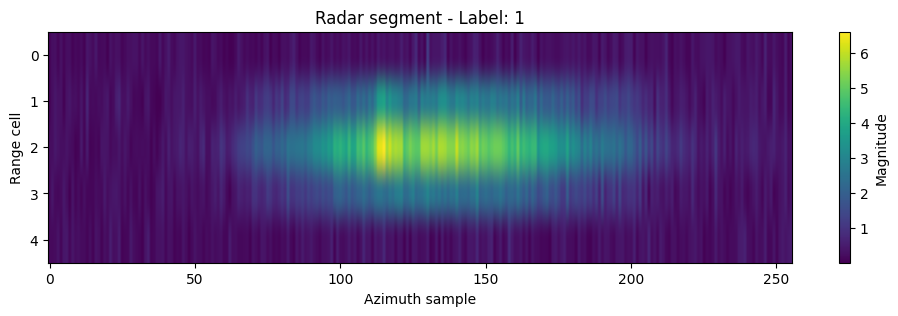

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

plt.imshow(
    X_train[0],
    aspect="auto"
)

plt.xlabel("Azimuth sample")
plt.ylabel("Range cell")
plt.title(f"Radar segment - Label: {y_train[0]}")

plt.colorbar(label="Magnitude")
plt.show()

In [17]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(2.881262729124236), 1: np.float64(0.6049863154293534)}


In [18]:
# Keep azimuth indices 54 through 203
# Python slicing stops before 204
X_train_crop = X_train[:, :, 54:204]
X_val_crop   = X_val[:, :, 54:204]
X_test_crop  = X_test[:, :, 54:204]

print("Train:", X_train_crop.shape)
print("Validation:", X_val_crop.shape)
print("Test:", X_test_crop.shape)

print("\nMagnitude statistics:")
print("Min:", X_train_crop.min())
print("Max:", X_train_crop.max())
print("Mean:", X_train_crop.mean())
print("Std:", X_train_crop.std())

print("\nPercentiles:")
for p in [50, 90, 95, 99, 99.9]:
    print(f"{p}%:", np.percentile(X_train_crop, p))

Train: (56588, 5, 150)
Validation: (8000, 5, 150)
Test: (8000, 5, 150)

Magnitude statistics:
Min: 4.1695886e-05
Max: 143.27837
Mean: 1.8093815
Std: 3.265962

Percentiles:
50%: 0.65804857
90%: 4.590455
95%: 7.059991
99%: 15.304103
99.9%: 35.265335


In [19]:
X_train_log = np.log1p(X_train_crop)
X_val_log   = np.log1p(X_val_crop)
X_test_log  = np.log1p(X_test_crop)

In [20]:
mean = X_train_log.mean()
std = X_train_log.std()

X_train_norm = (X_train_log - mean) / (std + 1e-8)
X_val_norm   = (X_val_log - mean) / (std + 1e-8)
X_test_norm  = (X_test_log - mean) / (std + 1e-8)

print("Mean:", X_train_norm.mean())
print("Std:", X_train_norm.std())

Mean: -5.8652194e-08
Std: 1.0000006


In [21]:
X_train_nn = X_train_norm[..., np.newaxis]
X_val_nn   = X_val_norm[..., np.newaxis]
X_test_nn  = X_test_norm[..., np.newaxis]

print("Train:", X_train_nn.shape)
print("Validation:", X_val_nn.shape)
print("Test:", X_test_nn.shape)

Train: (56588, 5, 150, 1)
Validation: (8000, 5, 150, 1)
Test: (8000, 5, 150, 1)


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(5, 150, 1)),

    layers.Conv2D(
        32,
        kernel_size=(3, 5),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(1, 2)),

    layers.Conv2D(
        64,
        kernel_size=(3, 5),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(1, 2)),

    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 5, 150, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 150, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 75, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 75, 64)      │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 75, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 37, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 37, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 37, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,369 (446.75 KB)

 Trainable params: 113,921 (445.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [24]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train_nn,
    y_train,

    validation_data=(X_val_nn, y_val),

    epochs=10,
    batch_size=256,

    class_weight=class_weights,
    callbacks=callbacks,

    verbose=1
)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8788 - auc: 0.9548 - loss: 0.2742 - precision: 0.9767 - recall: 0.8743 - val_accuracy: 0.2500 - val_auc: 0.5079 - val_loss: 7.2742 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9284 - auc: 0.9820 - loss: 0.1705 - precision: 0.9871 - recall: 0.9255 - val_accuracy: 0.3266 - val_auc: 0.6746 - val_loss: 5.2313 - val_precision: 1.0000 - val_recall: 0.1022 - learning_rate: 0.0010
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9444 - auc: 0.9886 - loss: 0.1336 - precision: 0.9902 - recall: 0.9420 - val_accuracy: 0.5550 - val_auc: 0.8877 - val_loss: 1.9984 - val_precision: 0.9976 - val_recall: 0.4077 - learning_rate: 0.0010
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9529 - auc: 0.9916 - loss: 0.1139 - precision: 0.9917 - recall: 0.9509 - val_accuracy: 0.9545 - val_auc: 0.9920 - val_loss:

In [25]:
test_results = model.evaluate(
    X_test_nn,
    y_test,
    verbose=1
)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9644 - auc: 0.9916 - loss: 0.0958 - precision: 0.9687 - recall: 0.9843
loss: 0.0958
compile_metrics: 0.9644


In [26]:
y_prob = model.predict(X_test_nn).flatten()

y_pred = (y_prob >= 0.5).astype(int)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


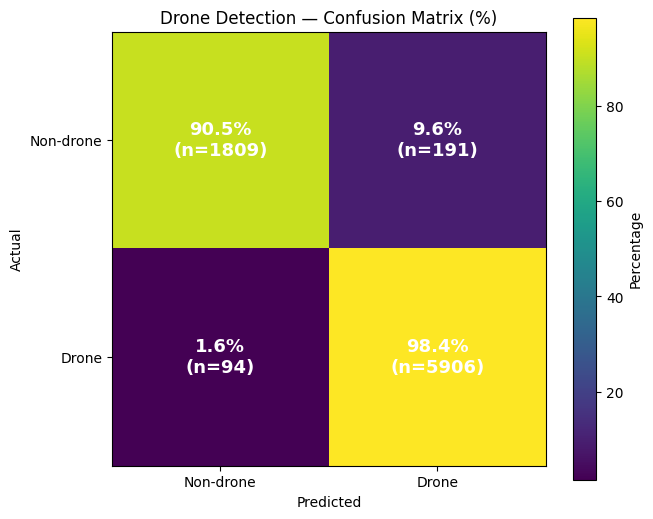

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Convert each row to percentages
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm_percent)

classes = ["Non-drone", "Drone"]

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Drone Detection — Confusion Matrix (%)")

# Put percentage and count inside each cell
for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            f"{cm_percent[i, j]:.1f}%\n(n={cm[i, j]})",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="white"
        )

plt.colorbar(im, label="Percentage")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-drone", "Drone"]
    )
)

              precision    recall  f1-score   support

   Non-drone       0.95      0.90      0.93      2000
       Drone       0.97      0.98      0.98      6000

    accuracy                           0.96      8000
   macro avg       0.96      0.94      0.95      8000
weighted avg       0.96      0.96      0.96      8000



In [36]:
model_filename = f"dd_{timestamp}.keras"
preprocessing_filename = f"drone_detector_preprocessing_{timestamp}.npz"

model.save(model_filename)

np.savez(
    preprocessing_filename,
    mean=mean,
    std=std
)

print("Model:", model_filename)
print("Preprocessing:", preprocessing_filename)

Model: dd_20260818_161008.keras
Preprocessing: drone_detector_preprocessing_20260818_161008.npz
